## Calculating Lift and drag

Currently we have 3 possibilities to compute lift $L$ and drag $D$ on the cylinder as a function of time $t$, each suited for different geometry representation. The purpose of this notebook is to use these three methods to compute the lift and drag in both a meshed and immersed setting to and compare the results.



In [1]:
# variable parameters
results_path = "../../../results/brinkman_parameters/dt_check/"
meshed_path = "meshed/"
brinkman_path = "brinkman/"

# plotting parameter
lift_axis = [-0.1, 0.1]
drag_axis = [0, 1.5]

### Method 1: A surface integral.

If one has a fully meshed geometry, the most natural way to compute lift and drag is by computing a surface integral of the pressure and viscous components, and projecting on the $x$ and $y$ directions. Fortunately, this functionality exists as a `simulation_component` known as `force_torque`. Hence, $L(t)$ and $D(t)$ can be read directly from the log file.

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt



log_name = "cylinder.log"
# note!
# I bet this isn't the best for long logfiles!
t_list = []
fx_list = []
fy_list = []

with open(results_path+meshed_path+log_name) as file:
    for line in file:
        s = line.rstrip()
        index = s.find("forcex")
        if index >= 1:
            numbers = np.array(line.rstrip().split())
            t_list.append(numbers[1].astype(float))
            fx_list.append(numbers[2].astype(float))
        index = s.find("forcey")
        if index >= 1:
            numbers = np.array(line.rstrip().split())
            fy_list.append(numbers[2].astype(float))
        
meshed_t = np.array(t_list)
meshed_drag = np.array(fx_list)
meshed_lift = np.array(fy_list)

### Method 2: Surface integral via probes

Abbas will do this

### Method 3: Total force excerted by the Brinkman term

The Brinkman style immersed boundary method imposes the presence of the geometry by the inclusion of a forcing term $\mathbf{f} = \chi \mathbf{u}$ where $\chi \in [0, \bar{\chi}]$ is a scalar field taking the maximum value $\chi  = \bar{\chi}$ in the solid region (forcing the velocity $\mathbf{u} << 1$) and taking the value $\chi = 0$ in the fluid region, recovering the standard Navier-Stokes equations.

By integrating this term in the domain one can calculate the total force excerted without requiring explicit knowledge of the interface location, ie,

$L = \int_\Omega \chi v \, d\Omega$ 

and 

$D = \int_\Omega \chi u \, d\Omega$

This has also been calcuated in the subroutine `user_calc_quantities` in `cylinder.f90`.

In [3]:
t_list = []
fx_list = []
fy_list = []

with open(results_path+brinkman_path+log_name) as file:
    for line in file:
        s = line.rstrip()
        index = s.find("Lift")
        if index >= 1:
            numbers = np.array(line.rstrip().split())
            t_list.append(numbers[4].astype(float))
            fy_list.append(numbers[2].astype(float))
        index = s.find("Drag")
        if index >= 1:
            numbers = np.array(line.rstrip().split())
            fx_list.append(numbers[2].astype(float))

brinkman_t = np.array(t_list)
brinkman_drag = np.array(fx_list)
brinkman_lift = np.array(fy_list)

## Visualization

**Note:** We should probably be plotting $C_L$ and $C_D$ when it comes time to looking at different Reynolds numbers!

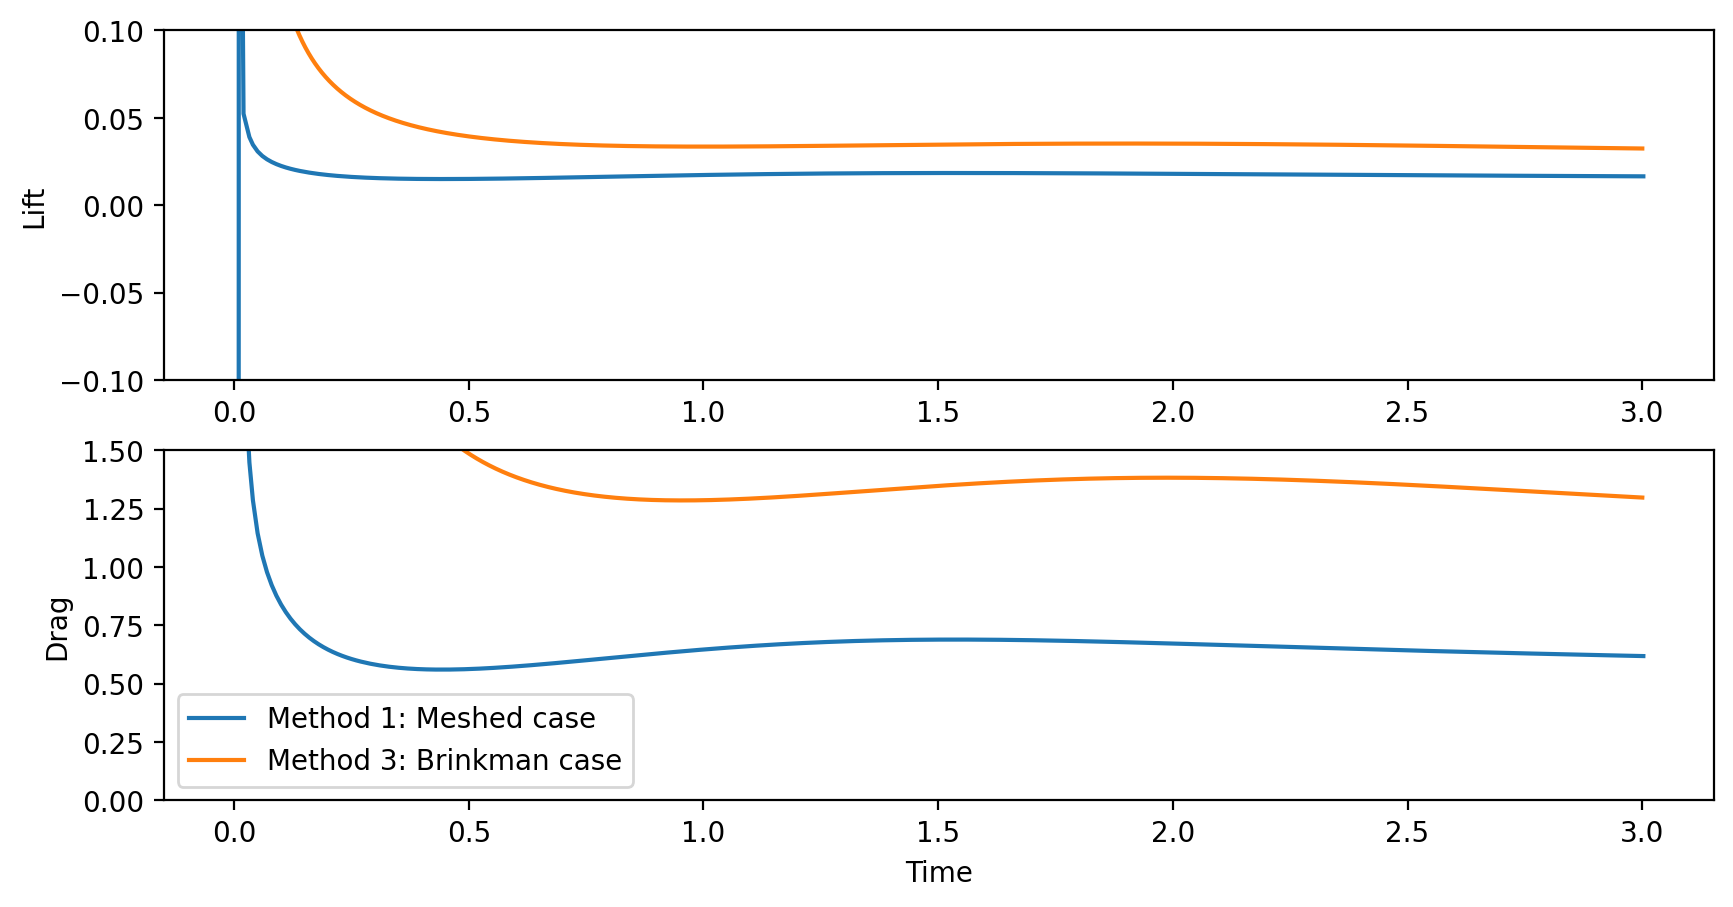

In [4]:
fig, ax = plt.subplots(2,1, figsize=(10, 5), dpi = 200)
ax[0].plot(meshed_t, meshed_lift)
ax[0].plot(brinkman_t, brinkman_lift)
ax[0].set_ylim(lift_axis)
ax[0].set_ylabel("Lift")

meshed_line, = ax[1].plot(meshed_t, meshed_drag)
brinkman_line, = ax[1].plot(brinkman_t, brinkman_drag)
ax[1].set_ylim(drag_axis)
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Drag")
ax[1].legend([meshed_line, brinkman_line], ['Method 1: Meshed case', 'Method 3: Brinkman case'])
plt.show()